# WiDS Global Datathon 2026
## Survival analysis for wildfire threat timing

**Upgrade: Family-aware Feature Selection + Fine RSF/GBM Blend Sweep + Platt Calibration + Direct Horizon LR**

Notebook ini menekankan pendekatan yang lebih stabil untuk dataset tabular kecil:
- Feature engineering domain-aware
- Feature selection yang dibatasi per keluarga fitur
- Repeated CV untuk stabilitas OOF
- Blend RSF + GBM dengan sweep alpha yang rapat
- Calibration ringan sebagai kandidat, bukan default
- Direct horizon model sebagai lane tambahan

In [23]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import optuna

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
BLEND_SEEDS = [42, 2026, 7, 123, 31415, 99, 777, 2024, 13, 101]
N_SPLITS = 5
N_REPEATS = 5
OPTUNA_TRIALS = 30
HORIZONS = np.array([12.0, 24.0, 48.0, 72.0])
COMP_HORIZONS = np.array([24.0, 48.0, 72.0])
DIRECT_HORIZONS = np.array([12.0, 24.0, 48.0])
ALPHA_GRID = np.round(np.arange(0.50, 0.761, 0.01), 2)
PLATT_HORIZONS = np.array([24.0, 48.0, 72.0])
RISK_WEIGHTS = np.array([0.1, 0.2, 0.3, 0.4])
FEATURE_FAMILY_CAPS = {
    "distance_direction": 8,
    "growth": 5,
    "temporal": 5,
    "calendar": 2,
    "rank": 3,
    "other": 2,
}
MAX_SELECTED_FEATURES = 24
MIN_SELECTED_FEATURES = 18
PLATT_C = 1.0
DIRECT_LR_C = 0.35
ID_COL = "event_id"
TIME_COL = "time_to_hit_hours"
EVENT_COL = "event"
DATA_DIR = Path(".")

train_raw = pd.read_csv(DATA_DIR / "train.csv")
test_raw = pd.read_csv(DATA_DIR / "test.csv")
meta = pd.read_csv(DATA_DIR / "metaData.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")
feature_cols_raw = [c for c in train_raw.columns if c not in {ID_COL, TIME_COL, EVENT_COL}]
print("Train shape:", train_raw.shape)
print("Test shape :", test_raw.shape)

Train shape: (221, 37)
Test shape : (95, 35)


## 1. Data Understanding

Memahami struktur data, target, missingness, dan bagaimana censoring membentuk evaluasi.

In [24]:
def qbin(series, q=4):
    ranked = series.rank(method="first")
    n_bins = min(q, ranked.nunique())
    return pd.qcut(ranked, q=n_bins, duplicates="drop")


target_summary = pd.DataFrame({
    "metric": ["rows", "event_rate", "median_time_to_hit", "time_q25", "time_q75"],
    "value": [
        len(train_raw),
        round(train_raw[EVENT_COL].mean(), 4),
        train_raw[TIME_COL].median(),
        train_raw[TIME_COL].quantile(0.25),
        train_raw[TIME_COL].quantile(0.75),
    ],
})

feature_groups = meta["category"].value_counts().rename_axis("category").reset_index(name="n_columns").sort_values("n_columns", ascending=False)

missing_train = train_raw[feature_cols_raw].isna().mean().sort_values(ascending=False).rename("missing_rate").reset_index().rename(columns={"index": "feature"})

strata_preview = pd.DataFrame({
    "event": train_raw[EVENT_COL].astype(int),
    "time_bin": np.where(train_raw[TIME_COL] <= 12.0, "le12", "gt12"),
})
strata_preview["strata"] = strata_preview["event"].astype(str) + "_" + strata_preview["time_bin"]

horizon_at_risk = []
for h in HORIZONS:
    y_h = ((train_raw[EVENT_COL] == 1) & (train_raw[TIME_COL] <= h)).astype(int)
    mask_h = ~((train_raw[EVENT_COL] == 0) & (train_raw[TIME_COL] < h))
    horizon_at_risk.append({
        "horizon": int(h), "at_risk_n": int(mask_h.sum()),
        "positives_among_at_risk": int(y_h[mask_h].sum()),
        "event_rate_among_at_risk": float(y_h[mask_h].mean()),
        "excluded_by_censoring": int((~mask_h).sum()),
    })
horizon_at_risk = pd.DataFrame(horizon_at_risk)

corr_rows = []
for col in feature_cols_raw:
    s = train_raw[col]
    corr_rows.append({
        "feature": col, "missing_rate": float(s.isna().mean()),
        "zero_rate": float((s == 0).mean()), "skew": float(s.skew()),
        "abs_corr_event": float(abs(s.corr(train_raw[EVENT_COL]))),
        "abs_corr_time": float(abs(s.corr(train_raw[TIME_COL]))),
    })
corr_summary = pd.DataFrame(corr_rows).sort_values("abs_corr_event", ascending=False)

display(target_summary)
display(feature_groups)
display(missing_train.head(12))
display(strata_preview["strata"].value_counts().sort_index().rename_axis("strata").reset_index(name="count"))
display(horizon_at_risk)
display(corr_summary.head(12))

,metric,value
0,rows,221.000000
1,event_rate,0.312200
2,median_time_to_hit,43.109830
3,time_q25,12.242322
4,time_q75,63.938706


,category,n_columns
0,growth,10
1,distance,9
2,centroid_kinematics,5
3,directionality,4
4,temporal_coverage,3
5,temporal_metadata,3
6,target,2
7,identifier,1


,feature,missing_rate
0,num_perimeters_0_5h,0.0
1,dt_first_last_0_5h,0.0
2,low_temporal_resolution_0_5h,0.0
3,area_first_ha,0.0
4,area_growth_abs_0_5h,0.0
5,area_growth_rel_0_5h,0.0
6,area_growth_rate_ha_per_h,0.0
7,log1p_area_first,0.0
8,log1p_growth,0.0
9,log_area_ratio_0_5h,0.0


,strata,count
0,0_gt12,146
1,0_le12,6
2,1_gt12,20
3,1_le12,49


,horizon,at_risk_n,positives_among_at_risk,event_rate_among_at_risk,excluded_by_censoring
0,12,215,49,0.227907,6
1,24,196,63,0.321429,25
2,48,166,66,0.397590,55
3,72,69,69,1.000000,152


,feature,missing_rate,zero_rate,skew,abs_corr_event,abs_corr_time
18,dist_min_ci_0_5h,0.0,0.000000,1.634553,0.481379,0.324876
2,low_temporal_resolution_0_5h,0.0,0.271493,-1.034656,0.379117,0.442236
0,num_perimeters_0_5h,0.0,0.000000,3.174066,0.370501,0.392040
1,dt_first_last_0_5h,0.0,0.723982,1.408768,0.352954,0.434699
28,alignment_abs,0.0,0.723982,1.614478,0.349115,0.366923
17,spread_bearing_cos,0.0,0.000000,-3.486537,0.323189,0.370451
8,log1p_growth,0.0,0.891403,3.635148,0.292688,0.317451
15,spread_bearing_deg,0.0,0.886878,4.141749,0.281012,0.335598
9,log_area_ratio_0_5h,0.0,0.886878,6.337715,0.229327,0.228119
12,radial_growth_rate_m_per_h,0.0,0.886878,6.469868,0.214956,0.218137


## 2. Visualisasi Insight Inti

Dari eksplorasi awal, sinyal paling kuat datang dari **jarak ke evacuation zone**, **kecepatan penutupan (closing speed)**, dan **kualitas observasi**.

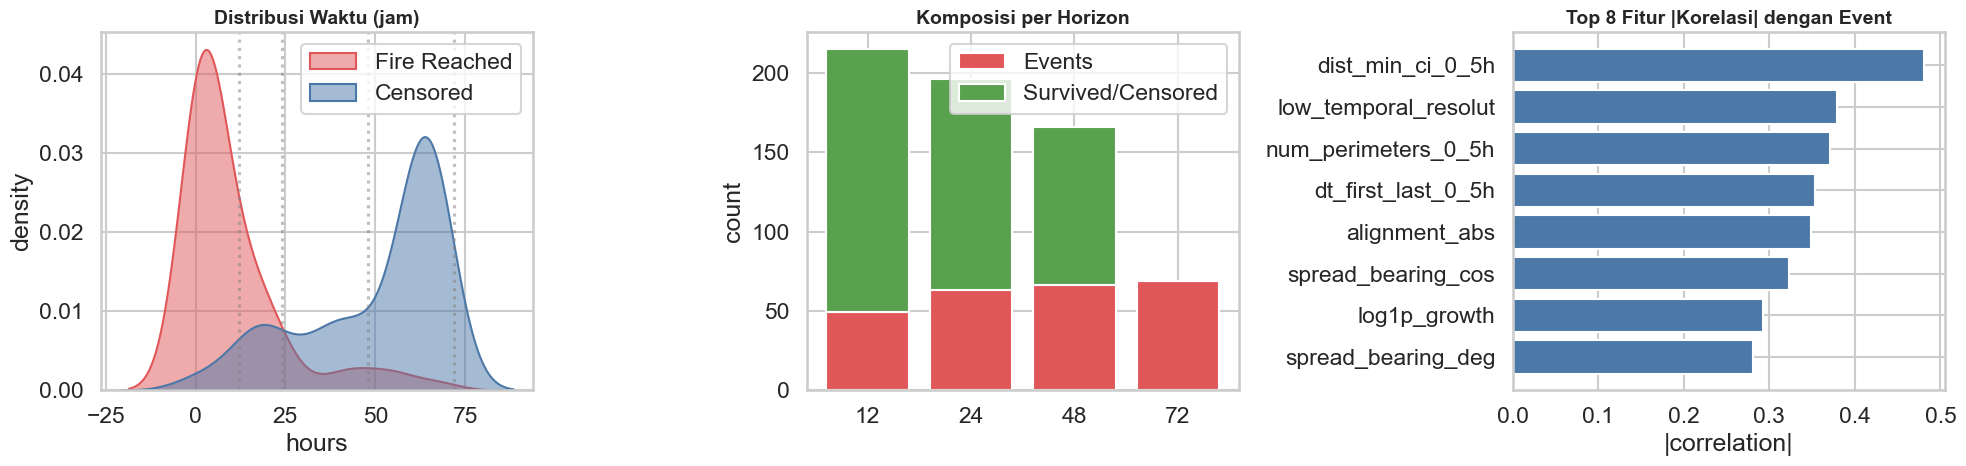

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax = axes[0]
for ev, color, label in [(1, "#e15759", "Fire Reached"), (0, "#4c78a8", "Censored")]:
    data = train_raw.loc[train_raw[EVENT_COL] == ev, TIME_COL]
    sns.kdeplot(data=data, fill=True, alpha=0.5, ax=ax, color=color, label=label)
for h in [12, 24, 48, 72]:
    ax.axvline(h, color="gray", linestyle=":", alpha=0.5)
ax.set_title("Distribusi Waktu (jam)", fontsize=14, fontweight="bold")
ax.set_xlabel("hours")
ax.set_ylabel("density")
ax.legend()

ax = axes[1]
tmp_df = horizon_at_risk.copy()
tmp_df.set_index("horizon", inplace=True)
ax.bar(tmp_df.index.astype(str), tmp_df["positives_among_at_risk"], color="#e15759", label="Events")
ax.bar(tmp_df.index.astype(str), tmp_df["at_risk_n"] - tmp_df["positives_among_at_risk"],
       bottom=tmp_df["positives_among_at_risk"], color="#59a14f", label="Survived/Censored")
ax.set_title("Komposisi per Horizon", fontsize=14, fontweight="bold")
ax.set_ylabel("count")
ax.legend()

ax = axes[2]
top_corr = corr_summary.head(8).sort_values("abs_corr_event")
ax.barh(top_corr["feature"].str[:20], top_corr["abs_corr_event"], color="#4c78a8")
ax.set_title("Top 8 Fitur |Korelasi| dengan Event", fontsize=14, fontweight="bold")
ax.set_xlabel("|correlation|")

plt.tight_layout()
plt.show()

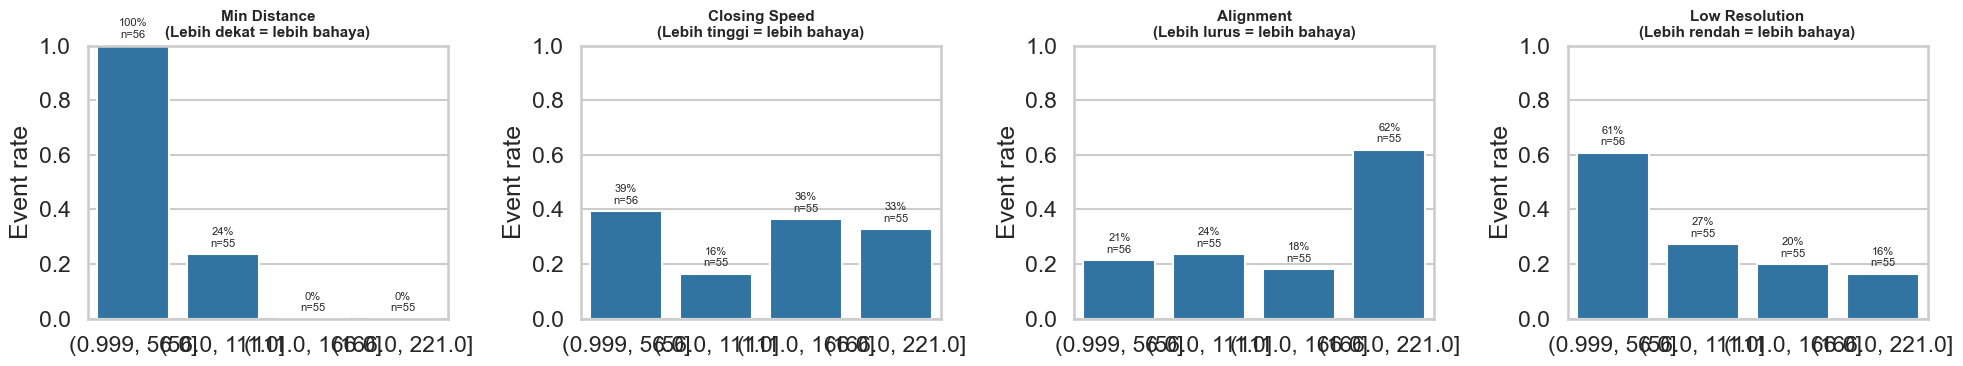

In [26]:
key_features = [
    ("dist_min_ci_0_5h", "Min Distance\n(Lebih dekat = lebih bahaya)"),
    ("closing_speed_m_per_h", "Closing Speed\n(Lebih tinggi = lebih bahaya)"),
    ("alignment_abs", "Alignment\n(Lebih lurus = lebih bahaya)"),
    ("low_temporal_resolution_0_5h", "Low Resolution\n(Lebih rendah = lebih bahaya)")
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (feat, title) in zip(axes, key_features):
    tmp = train_raw[[feat, EVENT_COL]].copy()
    tmp["_bin"] = qbin(tmp[feat], q=4)
    grp = tmp.groupby("_bin", observed=False)
    tbl = pd.DataFrame({"_bin": grp.size().index.astype(str), "rate": grp[EVENT_COL].mean().to_numpy(), "n": grp.size().to_numpy()})
    sns.barplot(data=tbl, x="_bin", y="rate", ax=ax, color="#1f77b4", edgecolor="white")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Event rate")
    ax.set_ylim(0, 1)
    for i, (r, n) in enumerate(zip(tbl["rate"], tbl["n"])):
        ax.text(i, r + 0.02, f"{r:.0%}\nn={n}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

### Key Insights

- **Distribusi waktu**: Event cenderung terjadi lebih cepat (median ~43 jam), dengan spike di early hours.
- **Censoring impact**: Horizon 72 jam kehilangan banyak sampel karena di-censor sebelum waktu itu.
- **Fitur terpenting**: `dist_min_ci_0_5h` memiliki korelasi tertinggi dengan event (~0.48), diikuti temporal resolution (~0.38).
- **Trend monoton**: Event rate berubah secara monoton seiring perubahan fitur kunci ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ sinyal kuat untuk model.

## 3. Feature Engineering

In [27]:
def fit_feature_reference(df: pd.DataFrame) -> dict:
    rank_cols = [
        "dist_min_ci_0_5h", "closing_speed_abs_m_per_h", "alignment_abs",
        "area_growth_rel_0_5h", "num_perimeters_0_5h", "dt_first_last_0_5h",
        "perimeter_density", "dist_pressure", "obs_quality",
    ]
    ref = {"rank_cols": rank_cols, "sorted_values": {}}
    for col in rank_cols:
        if col in df.columns:
            ref["sorted_values"][col] = np.sort(df[col].astype(float).to_numpy())
    return ref


def percentile_rank(values: np.ndarray, sorted_values: np.ndarray) -> np.ndarray:
    if sorted_values.size == 0:
        return np.zeros_like(values, dtype=float)
    return np.searchsorted(sorted_values, values, side="right") / float(sorted_values.size)


def add_engineered_features(df: pd.DataFrame, ref: dict | None = None):
    out = df.copy()
    out["hour_sin"] = np.sin(2 * np.pi * out["event_start_hour"] / 24.0)
    out["hour_cos"] = np.cos(2 * np.pi * out["event_start_hour"] / 24.0)
    out["dow_sin"] = np.sin(2 * np.pi * out["event_start_dayofweek"] / 7.0)
    out["dow_cos"] = np.cos(2 * np.pi * out["event_start_dayofweek"] / 7.0)
    out["month_sin"] = np.sin(2 * np.pi * out["event_start_month"] / 12.0)
    out["month_cos"] = np.cos(2 * np.pi * out["event_start_month"] / 12.0)
    out["dist_min_log"] = np.log1p(out["dist_min_ci_0_5h"])
    out["closing_abs_log"] = np.log1p(out["closing_speed_abs_m_per_h"])
    out["growth_abs_log"] = np.log1p(np.clip(out["area_growth_abs_0_5h"], a_min=0.0, a_max=None))
    out["closing_pos"] = out["closing_speed_m_per_h"].clip(lower=0.0)
    out["closing_neg"] = (-out["closing_speed_m_per_h"]).clip(lower=0.0)
    out["dist_change_closing"] = (-out["dist_change_ci_0_5h"]).clip(lower=0.0)
    out["dist_change_widening"] = out["dist_change_ci_0_5h"].clip(lower=0.0)
    out["projected_advance_pos"] = out["projected_advance_m"].clip(lower=0.0)
    out["projected_advance_neg"] = (-out["projected_advance_m"]).clip(lower=0.0)
    out["dist_over_close"] = out["dist_min_ci_0_5h"] / (1.0 + out["closing_speed_abs_m_per_h"])
    out["dist_minus_proj"] = out["dist_min_ci_0_5h"] - out["projected_advance_m"]
    out["closing_alignment"] = out["closing_speed_abs_m_per_h"] * out["alignment_abs"]
    out["perimeter_density"] = out["num_perimeters_0_5h"] / (out["dt_first_last_0_5h"] + 0.25)
    out["perimeter_gap"] = out["dt_first_last_0_5h"] / out["num_perimeters_0_5h"]
    out["obs_quality"] = (1.0 - out["low_temporal_resolution_0_5h"]) * (1.0 + out["dt_first_last_0_5h"])
    if ref is None:
        ref = fit_feature_reference(out)
    for col in ref["rank_cols"]:
        if col in out.columns and col in ref["sorted_values"]:
            out[f"rank_{col}"] = percentile_rank(out[col].astype(float).to_numpy(), ref["sorted_values"][col])
    return out, ref


DROP_COLS = {ID_COL, TIME_COL, EVENT_COL}


def build_feature_frame(df: pd.DataFrame, ref: dict | None = None):
    engineered, ref = add_engineered_features(df, ref)
    feature_frame = engineered.drop(columns=[c for c in DROP_COLS if c in engineered.columns])
    return feature_frame, ref


engineered_preview, preview_ref = build_feature_frame(train_raw)
new_features = sorted([c for c in engineered_preview.columns if c not in train_raw.columns])
print(f"Total features after engineering: {len(engineered_preview.columns)}")
print(f"New engineered features: {len(new_features)}")

Total features after engineering: 63
New engineered features: 29


## 4. Feature Selection via Family-aware Permutation Importance

Less is more untuk dataset kecil, tetapi kita jaga representasi dari tiap keluarga fitur supaya model tidak kehilangan sinyal penting.


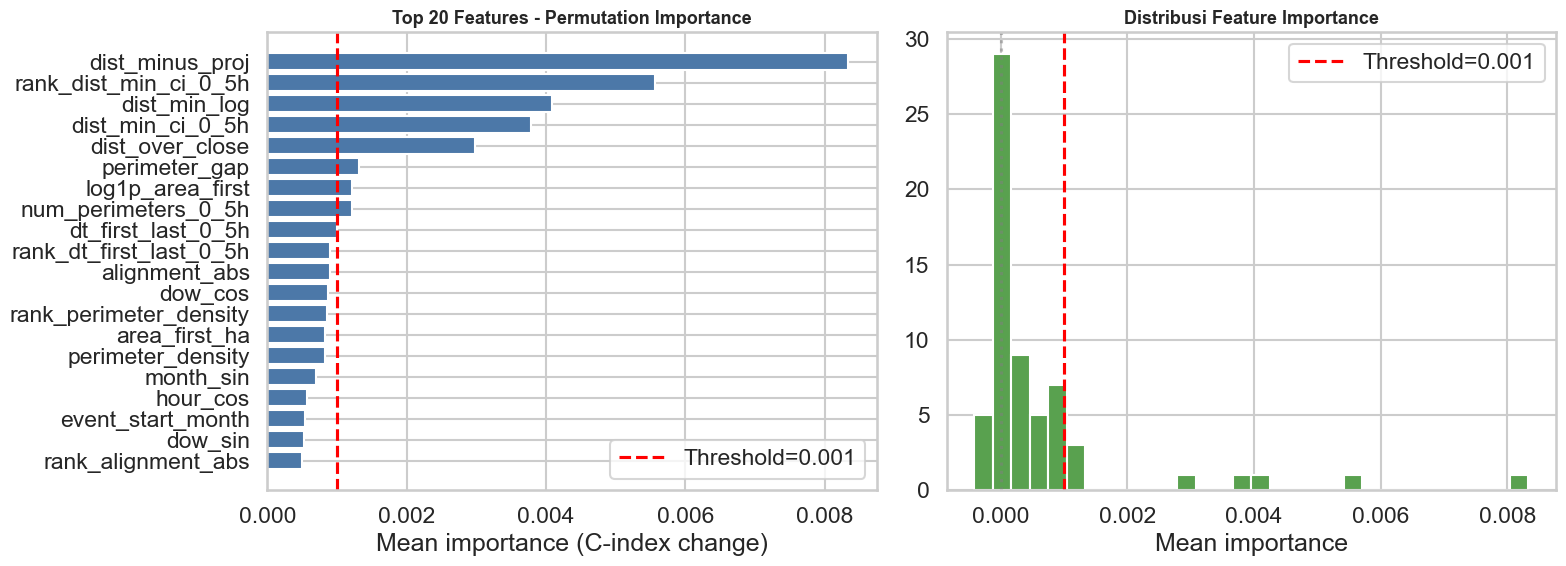

,total_importance,mean_importance,feature_count
family,,,
distance_direction,0.020316,0.000752,27
rank,0.008573,0.001072,8
temporal,0.005217,0.000869,6
calendar,0.004422,0.000491,9
growth,0.002004,0.000182,11
other,-0.000022,-0.000011,2


Dari 63 fitur, 20 fitur dipertahankan (threshold=0.001, top_k=30, min_keep=18, max_keep=24)


,feature,importance_mean,importance_std,family
50,dist_minus_proj,0.008331,0.002257,distance_direction
55,rank_dist_min_ci_0_5h,0.005565,0.001953,rank
40,dist_min_log,0.004085,0.001772,distance_direction
18,dist_min_ci_0_5h,0.003787,0.001480,distance_direction
49,dist_over_close,0.002981,0.001161,distance_direction
53,perimeter_gap,0.001319,0.000685,temporal
7,log1p_area_first,0.001215,0.000868,growth
0,num_perimeters_0_5h,0.001209,0.001006,temporal
1,dt_first_last_0_5h,0.000994,0.001077,temporal
60,rank_dt_first_last_0_5h,0.000900,0.001148,rank


In [28]:
def feature_family(name):
    if name.startswith("rank_"):
        return "rank"
    if name.startswith(("hour_", "dow_", "month_", "event_start_")):
        return "calendar"
    if name.startswith(("area_", "growth_", "radial_")) or name in {
        "log1p_area_first", "log1p_growth", "log_area_ratio_0_5h", "relative_growth_0_5h",
        "area_growth_abs_0_5h", "area_growth_rel_0_5h", "area_growth_rate_ha_per_h",
    }:
        return "growth"
    if name.startswith(("num_perimeters_", "dt_first_last_", "low_temporal_resolution_", "perimeter_density", "perimeter_gap", "obs_quality")):
        return "temporal"
    if name.startswith(("dist_", "closing_", "projected_advance_")) or name in {
        "alignment_cos", "alignment_abs", "cross_track_component", "along_track_speed",
        "spread_bearing_deg", "spread_bearing_sin", "spread_bearing_cos", "closing_alignment",
        "closing_pos", "closing_neg", "dist_change_closing", "dist_change_widening",
        "projected_advance_pos", "projected_advance_neg",
    }:
        return "distance_direction"
    return "other"


def select_important_features(X_train, y_train, feature_names, seed=42, threshold=0.001, min_keep=MIN_SELECTED_FEATURES, max_keep=MAX_SELECTED_FEATURES, top_k=30):
    rsf = RandomSurvivalForest(
        n_estimators=200, min_samples_split=8, min_samples_leaf=3,
        max_features="sqrt", random_state=seed, n_jobs=1,
    )
    rsf.fit(X_train, y_train)

    def cindex_scorer(estimator, X, y):
        preds = estimator.predict(X)
        return concordance_index_censored(y["event"], y["time"], preds)[0]

    result = permutation_importance(
        rsf, X_train, y_train, n_repeats=15, random_state=seed,
        scoring=cindex_scorer,
    )
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }).sort_values("importance_mean", ascending=False)
    importance_df["family"] = importance_df["feature"].map(feature_family)

    family_report = importance_df.groupby("family", observed=False).agg(
        total_importance=("importance_mean", "sum"),
        mean_importance=("importance_mean", "mean"),
        feature_count=("feature", "count"),
    ).sort_values("total_importance", ascending=False)

    candidate_pool = importance_df.head(top_k)
    selected = []
    family_counts = {k: 0 for k in FEATURE_FAMILY_CAPS}
    for row in candidate_pool.itertuples(index=False):
        cap = FEATURE_FAMILY_CAPS.get(row.family, FEATURE_FAMILY_CAPS["other"])
        if family_counts.get(row.family, 0) >= cap:
            continue
        selected.append(row.feature)
        family_counts[row.family] = family_counts.get(row.family, 0) + 1
        if len(selected) >= max_keep:
            break

    if len(selected) < min_keep:
        for feat in importance_df["feature"].tolist():
            if feat not in selected:
                selected.append(feat)
            if len(selected) >= min_keep:
                break

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    top20 = importance_df.head(20)
    ax[0].barh(top20["feature"][::-1], top20["importance_mean"][::-1], color="#4c78a8")
    ax[0].axvline(threshold, color="red", linestyle="--", label=f"Threshold={threshold}")
    ax[0].set_title("Top 20 Features - Permutation Importance", fontsize=13, fontweight="bold")
    ax[0].set_xlabel("Mean importance (C-index change)")
    ax[0].legend()
    ax[1].hist(importance_df["importance_mean"], bins=30, color="#59a14f", edgecolor="white")
    ax[1].axvline(threshold, color="red", linestyle="--", label=f"Threshold={threshold}")
    ax[1].axvline(0, color="gray", linestyle=":", alpha=0.5)
    ax[1].set_title("Distribusi Feature Importance", fontsize=13, fontweight="bold")
    ax[1].set_xlabel("Mean importance")
    ax[1].legend()
    plt.tight_layout()
    plt.show()

    display(family_report)
    print(f"Dari {len(feature_names)} fitur, {len(selected)} fitur dipertahankan (threshold={threshold}, top_k={top_k}, min_keep={min_keep}, max_keep={max_keep})")
    return selected, importance_df, family_report


y_full_for_select = Surv.from_arrays(
    event=train_raw[EVENT_COL].astype(bool).to_numpy(),
    time=train_raw[TIME_COL].astype(float).to_numpy()
)
prep_for_select = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
]).fit(engineered_preview)
X_for_select = prep_for_select.transform(engineered_preview)
feature_names = engineered_preview.columns.tolist()

selected_features, importance_report, family_importance_report = select_important_features(
    X_for_select, y_full_for_select, feature_names, seed=42, threshold=0.001, min_keep=MIN_SELECTED_FEATURES, max_keep=MAX_SELECTED_FEATURES, top_k=30
)
display(importance_report.head(25))

## 5. Utility Functions & Model Definitions

In [29]:
def make_surv_target(df):
    return Surv.from_arrays(event=df[EVENT_COL].astype(bool).to_numpy(), time=df[TIME_COL].astype(float).to_numpy())


def make_strata(df):
    time_bin = pd.cut(df[TIME_COL], bins=[-np.inf, 12.0, 48.0, np.inf], labels=["le12", "le48", "gt48"])
    return df[EVENT_COL].astype(int).astype(str) + "_" + time_bin.astype(str)


def horizon_labels(df, horizon):
    y = ((df[EVENT_COL] == 1) & (df[TIME_COL] <= horizon)).astype(int).to_numpy()
    mask = ~((df[EVENT_COL] == 0) & (df[TIME_COL] < horizon))
    return y, mask.to_numpy()


def horizon_brier_from_vector(df, pred, horizon):
    y, mask = horizon_labels(df, horizon)
    return float(mean_squared_error(y[mask], pred[mask]))


def predict_horizon_probs(model, model_type, X, horizons):
    probs = np.zeros((X.shape[0], len(horizons)), dtype=float)
    if model_type in ("sklearn_gbm", "rsf"):
        surv_fns = model.predict_survival_function(X)
        for i, fn in enumerate(surv_fns):
            max_x = (float(fn.x[-1]) - 1e-9) if hasattr(fn, "x") else float(horizons.max())
            probs[i, :] = 1.0 - np.array([float(fn(min(float(h), max_x))) for h in horizons], dtype=float)
    elif model_type in ("lgb", "xgb", "cb"):
        risk_scores = model.predict(X)
        for h_idx, h in enumerate(horizons):
            median_risk = np.median(risk_scores)
            scaled = (risk_scores - median_risk) / (np.std(risk_scores) + 1e-8)
            probs[:, h_idx] = 1.0 / (1.0 + np.exp(-scaled * (h / 24.0)))
    elif model_type == "cox":
        risk_scores = model.predict(X)
        for h_idx, h in enumerate(horizons):
            median_risk = np.median(risk_scores)
            scaled = (risk_scores - median_risk) / (np.std(risk_scores) + 1e-8)
            probs[:, h_idx] = 1.0 / (1.0 + np.exp(-scaled * (h / 24.0)))
    return np.clip(probs, 0.0, 1.0)


def monotone_probs(prob_matrix):
    return np.clip(np.maximum.accumulate(np.asarray(prob_matrix, dtype=float), axis=1), 0.0, 1.0)


def single_horizon_brier(df, probs, horizon):
    idx = int(np.where(HORIZONS == horizon)[0][0])
    y, mask = horizon_labels(df, horizon)
    return float(mean_squared_error(y[mask], probs[mask, idx]))


def weighted_brier_score(df, probs):
    probs = monotone_probs(probs)
    brier_by_h = {}
    for h in COMP_HORIZONS:
        idx = int(np.where(HORIZONS == h)[0][0])
        y, mask = horizon_labels(df, h)
        brier_by_h[h] = float(mean_squared_error(y[mask], probs[mask, idx]))
    weighted = 0.3 * brier_by_h[24.0] + 0.4 * brier_by_h[48.0] + 0.3 * brier_by_h[72.0]
    return weighted, brier_by_h


def evaluate_candidate(df, probs):
    probs = monotone_probs(np.asarray(probs, dtype=float))
    risk_score = probs @ RISK_WEIGHTS
    c_index = concordance_index_censored(
        df[EVENT_COL].astype(bool).to_numpy(),
        df[TIME_COL].astype(float).to_numpy(),
        risk_score,
    )[0]
    weighted_brier, brier_by_h = weighted_brier_score(df, probs)
    return {
        "c_index": float(c_index),
        "weighted_brier_24_48_72": float(weighted_brier),
        "hybrid_score": float(0.3 * c_index + 0.7 * (1.0 - weighted_brier)),
        "brier_12": float(single_horizon_brier(df, probs, 12.0)),
        "brier_24": float(brier_by_h[24.0]),
        "brier_48": float(brier_by_h[48.0]),
        "brier_72": float(brier_by_h[72.0]),
    }


def logit_clip(prob, eps=1e-6):
    prob = np.clip(np.asarray(prob, dtype=float), eps, 1.0 - eps)
    return np.log(prob / (1.0 - prob))


def fit_platt_calibrators(df, probs, horizons=PLATT_HORIZONS, seed=RANDOM_STATE, C=PLATT_C):
    probs = monotone_probs(np.asarray(probs, dtype=float))
    calibrators = {}
    for h in horizons:
        idx = int(np.where(HORIZONS == h)[0][0])
        y, mask = horizon_labels(df, h)
        x = probs[mask, idx]
        y_h = y[mask]
        if np.unique(y_h).size < 2 or np.unique(x).size < 2:
            calibrators[h] = None
            continue
        lr = LogisticRegression(C=C, solver="lbfgs", max_iter=2000, random_state=seed)
        lr.fit(logit_clip(x).reshape(-1, 1), y_h)
        calibrators[h] = lr
    return calibrators


def apply_platt_calibrators(probs, calibrators):
    probs = monotone_probs(np.asarray(probs, dtype=float).copy())
    for h, model in calibrators.items():
        if model is None:
            continue
        idx = int(np.where(HORIZONS == h)[0][0])
        probs[:, idx] = model.predict_proba(logit_clip(probs[:, idx]).reshape(-1, 1))[:, 1]
    return monotone_probs(probs)


def search_global_blend(oof_rsf, oof_gbm, df, alpha_grid=ALPHA_GRID):
    rows = []
    for alpha in alpha_grid:
        blend_probs = monotone_probs(alpha * oof_rsf + (1.0 - alpha) * oof_gbm)
        rows.append({"candidate": "raw_blend", "alpha_rsf": float(alpha), **evaluate_candidate(df, blend_probs)})
    report = pd.DataFrame(rows).sort_values("hybrid_score", ascending=False).reset_index(drop=True)
    best_alpha = float(report.loc[0, "alpha_rsf"])
    best_probs = monotone_probs(best_alpha * oof_rsf + (1.0 - best_alpha) * oof_gbm)
    return report, best_alpha, best_probs


def search_horizon_blend(oof_rsf, oof_gbm, df, alpha_grid=ALPHA_GRID):
    probs = np.zeros_like(oof_rsf)
    rows = []
    alpha_by_h = {}
    for h in HORIZONS:
        idx = int(np.where(HORIZONS == h)[0][0])
        best_alpha = None
        best_brier = np.inf
        for alpha in alpha_grid:
            pred = alpha * oof_rsf[:, idx] + (1.0 - alpha) * oof_gbm[:, idx]
            brier = horizon_brier_from_vector(df, pred, h)
            if brier < best_brier:
                best_brier = brier
                best_alpha = float(alpha)
        alpha_by_h[float(h)] = best_alpha
        probs[:, idx] = best_alpha * oof_rsf[:, idx] + (1.0 - best_alpha) * oof_gbm[:, idx]
        rows.append({"horizon": float(h), "alpha_rsf": best_alpha, "horizon_brier": float(best_brier)})
    probs = monotone_probs(probs)
    return probs, alpha_by_h, pd.DataFrame(rows)


def fit_direct_horizon_lr(X_train, df_train, horizons=DIRECT_HORIZONS, seed=RANDOM_STATE, C=DIRECT_LR_C):
    models = {}
    for h in horizons:
        y_h, mask = horizon_labels(df_train, h)
        X_h = X_train[mask]
        y_h = y_h[mask]
        if X_h.shape[0] == 0 or np.unique(y_h).size < 2:
            models[float(h)] = None
            continue
        lr = LogisticRegression(
            C=C, solver="lbfgs", max_iter=2000, class_weight="balanced", random_state=seed,
        )
        lr.fit(X_h, y_h)
        models[float(h)] = lr
    return models


def predict_direct_horizon_lr(models, X, tail_anchor_probs=None):
    probs = np.zeros((X.shape[0], len(HORIZONS)), dtype=float)
    for idx, h in enumerate(HORIZONS):
        model = models.get(float(h))
        if model is not None:
            probs[:, idx] = model.predict_proba(X)[:, 1]
        elif tail_anchor_probs is not None:
            probs[:, idx] = tail_anchor_probs[:, idx]
        elif idx == 0:
            probs[:, idx] = 0.0
        else:
            probs[:, idx] = probs[:, idx - 1]
    if tail_anchor_probs is not None:
        idx72 = int(np.where(HORIZONS == 72.0)[0][0])
        idx48 = int(np.where(HORIZONS == 48.0)[0][0])
        probs[:, idx72] = np.maximum(probs[:, idx48], tail_anchor_probs[:, idx72])
    return monotone_probs(probs)

In [30]:
def build_sklearn_models(seed=RANDOM_STATE):
    return {
        "cox": (CoxPHSurvivalAnalysis(alpha=2.0), "cox"),
        "rsf": (RandomSurvivalForest(
            n_estimators=300, min_samples_split=10, min_samples_leaf=4,
            max_features="sqrt", random_state=seed, n_jobs=1,
        ), "rsf"),
        "gbm": (GradientBoostingSurvivalAnalysis(
            n_estimators=300, learning_rate=0.02, max_depth=2,
            min_samples_leaf=5, subsample=0.8, random_state=seed,
        ), "sklearn_gbm"),
    }


def build_lgb_model(params, seed=RANDOM_STATE):
    return (lgb.LGBMClassifier(**params, objective="binary", verbose=-1, random_state=seed), "lgb")


def build_xgb_model(params, seed=RANDOM_STATE):
    return (xgb.XGBClassifier(**params, random_state=seed), "xgb")


def build_cb_model(params, seed=RANDOM_STATE):
    p = params.copy()
    p["verbose"] = False
    p["random_seed"] = seed
    return (cb.CatBoostClassifier(**p), "cb")

In [31]:
def tune_boosting_models(X_train, y_event, n_trials=OPTUNA_TRIALS, seed=RANDOM_STATE):
    params_store = {}

    def obj_lgb(trial):
        param = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 600, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 8, 31),
            "max_depth": trial.suggest_int("max_depth", 2, 5),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 20),
            "subsample": trial.suggest_float("subsample", 0.6, 0.95),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 0.8),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        }
        scores = []
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        for tr, va in skf.split(X_train, y_event):
            try:
                m = lgb.LGBMClassifier(**param, objective="binary", verbose=-1, random_state=seed)
                m.fit(X_train[tr], y_event[tr])
                scores.append(mean_squared_error(y_event[va], m.predict_proba(X_train[va])[:, 1]))
            except Exception:
                return float("inf")
        return np.mean(scores)

    print("Tuning LightGBM...")
    study_lgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=seed))
    study_lgb.optimize(obj_lgb, n_trials=n_trials, show_progress_bar=False)
    params_store["lgb"] = study_lgb.best_params
    print(f"  Best LightGBM: {study_lgb.best_params}")

    def obj_xgb(trial):
        param = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 600, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
            "max_depth": trial.suggest_int("max_depth", 2, 5),
            "min_child_weight": trial.suggest_int("min_child_weight", 3, 15),
            "subsample": trial.suggest_float("subsample", 0.5, 0.9),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.7),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        }
        scores = []
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        for tr, va in skf.split(X_train, y_event):
            try:
                m = xgb.XGBClassifier(**param, random_state=seed)
                m.fit(X_train[tr], y_event[tr], verbose=False)
                scores.append(mean_squared_error(y_event[va], m.predict_proba(X_train[va])[:, 1]))
            except Exception:
                return float("inf")
        return np.mean(scores)

    print("Tuning XGBoost...")
    study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=seed))
    study_xgb.optimize(obj_xgb, n_trials=n_trials, show_progress_bar=False)
    params_store["xgb"] = study_xgb.best_params
    print(f"  Best XGBoost: {study_xgb.best_params}")

    def obj_cb(trial):
        param = {
            "iterations": trial.suggest_int("iterations", 200, 600, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
            "depth": trial.suggest_int("depth", 2, 5),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 0.9),
            "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.3, 0.8),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 20),
        }
        scores = []
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        for tr, va in skf.split(X_train, y_event):
            try:
                m = cb.CatBoostClassifier(**param, verbose=False, random_seed=seed)
                m.fit(X_train[tr], y_event[tr], verbose=False)
                scores.append(mean_squared_error(y_event[va], m.predict_proba(X_train[va])[:, 1]))
            except Exception:
                return float("inf")
        return np.mean(scores)

    print("Tuning CatBoost...")
    study_cb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=seed))
    study_cb.optimize(obj_cb, n_trials=n_trials, show_progress_bar=False)
    params_store["cb"] = study_cb.best_params
    print(f"  Best CatBoost: {study_cb.best_params}")

    return params_store


X_train_all, ref = build_feature_frame(train_raw)
X_test_all, _ = build_feature_frame(test_raw, ref)
X_train_sel = X_train_all[selected_features]
X_test_sel = X_test_all[selected_features]
preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]).fit(X_train_sel)
X_train = preprocessor.transform(X_train_sel)
X_test = preprocessor.transform(X_test_sel)
y_event = train_raw[EVENT_COL].astype(int).to_numpy()

best_params = tune_boosting_models(X_train, y_event, n_trials=OPTUNA_TRIALS, seed=RANDOM_STATE)

[I 2026-04-08 11:38:21,199] A new study created in memory with name: no-name-26d622cb-ed70-47d7-9c31-9f6c93a29e90


Tuning LightGBM...


[I 2026-04-08 11:38:21,413] Trial 0 finished with value: 0.010984230727181797 and parameters: {'n_estimators': 350, 'learning_rate': 0.044635901521768134, 'num_leaves': 25, 'max_depth': 4, 'min_child_samples': 7, 'subsample': 0.6545980821176709, 'colsample_bytree': 0.4232334448672798, 'reg_alpha': 5.3994844097874335, 'reg_lambda': 1.5930522616241019}. Best is trial 0 with value: 0.010984230727181797.
[I 2026-04-08 11:38:21,815] Trial 1 finished with value: 0.009604112396348211 and parameters: {'n_estimators': 500, 'learning_rate': 0.005242693862597309, 'num_leaves': 31, 'max_depth': 5, 'min_child_samples': 8, 'subsample': 0.6636387385224852, 'colsample_bytree': 0.47336180394137356, 'reg_alpha': 0.4059611610484306, 'reg_lambda': 1.1207606211860568}. Best is trial 1 with value: 0.009604112396348211.
[I 2026-04-08 11:38:22,085] Trial 2 finished with value: 0.010328970008954438 and parameters: {'n_estimators': 350, 'learning_rate': 0.009776854331372627, 'num_leaves': 22, 'max_depth': 2, 'm

  Best LightGBM: {'n_estimators': 500, 'learning_rate': 0.011293180244589642, 'num_leaves': 13, 'max_depth': 3, 'min_child_samples': 16, 'subsample': 0.8276322431799303, 'colsample_bytree': 0.6061778085339886, 'reg_alpha': 0.15564449150146875, 'reg_lambda': 0.23637784975370563}
Tuning XGBoost...


[I 2026-04-08 11:38:33,462] Trial 0 finished with value: 0.08434274196624755 and parameters: {'n_estimators': 350, 'learning_rate': 0.044635901521768134, 'max_depth': 4, 'min_child_weight': 10, 'subsample': 0.5624074561769746, 'colsample_bytree': 0.362397808134481, 'reg_alpha': 0.13066739238053282, 'reg_lambda': 5.3994844097874335}. Best is trial 0 with value: 0.08434274196624755.
[I 2026-04-08 11:38:34,195] Trial 1 finished with value: 0.11662476807832718 and parameters: {'n_estimators': 450, 'learning_rate': 0.025529516046973785, 'max_depth': 2, 'min_child_weight': 15, 'subsample': 0.8329770563201687, 'colsample_bytree': 0.38493564427131044, 'reg_alpha': 0.23102018878452935, 'reg_lambda': 0.2327067708383781}. Best is trial 0 with value: 0.08434274196624755.
[I 2026-04-08 11:38:34,850] Trial 2 finished with value: 0.015386471711099147 and parameters: {'n_estimators': 300, 'learning_rate': 0.016738881542579662, 'max_depth': 3, 'min_child_weight': 6, 'subsample': 0.7447411578889518, 'co

  Best XGBoost: {'n_estimators': 600, 'learning_rate': 0.01091400500998756, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.6756750277510088, 'colsample_bytree': 0.5403925190005665, 'reg_alpha': 0.8399037432330653, 'reg_lambda': 2.79359092090352}
Tuning CatBoost...


[I 2026-04-08 11:39:04,231] Trial 0 finished with value: 0.00010523771940713221 and parameters: {'iterations': 350, 'learning_rate': 0.044635901521768134, 'depth': 4, 'l2_leaf_reg': 6.009974718380312, 'subsample': 0.5624074561769746, 'colsample_bylevel': 0.3779972601681013, 'min_data_in_leaf': 5}. Best is trial 0 with value: 0.00010523771940713221.
[I 2026-04-08 11:39:08,284] Trial 1 finished with value: 0.00010126735522064216 and parameters: {'iterations': 550, 'learning_rate': 0.019956529392808398, 'depth': 4, 'l2_leaf_reg': 1.0636066512540283, 'subsample': 0.8879639408647977, 'colsample_bylevel': 0.7162213204002108, 'min_data_in_leaf': 8}. Best is trial 1 with value: 0.00010126735522064216.
[I 2026-04-08 11:39:09,740] Trial 2 finished with value: 0.0016860023312589578 and parameters: {'iterations': 250, 'learning_rate': 0.007627364729026304, 'depth': 3, 'l2_leaf_reg': 4.816414530907083, 'subsample': 0.6727780074568463, 'colsample_bylevel': 0.44561457009902095, 'min_data_in_leaf': 14

  Best CatBoost: {'iterations': 550, 'learning_rate': 0.018155696333760744, 'depth': 2, 'l2_leaf_reg': 5.5640108969735635, 'subsample': 0.7128566105134372, 'colsample_bylevel': 0.6555963017538204, 'min_data_in_leaf': 16}


## 6. Repeated CV Evaluation

In [33]:
strata_labels = make_strata(train_raw)
cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)
splits = list(cv.split(np.zeros(len(train_raw)), strata_labels))
total_folds = len(splits)

sklearn_names = list(build_sklearn_models(RANDOM_STATE).keys())
boost_names = ["lgb", "xgb", "cb"]
all_names = sklearn_names + boost_names

oof_preds = {name: np.zeros((len(train_raw), len(HORIZONS)), dtype=float) for name in all_names}
test_preds = {name: np.zeros((len(test_raw), len(HORIZONS)), dtype=float) for name in all_names}
direct_oof_preds = np.zeros((len(train_raw), len(HORIZONS)), dtype=float)
oof_counts = np.zeros(len(train_raw), dtype=float)
fold_rows = []

for fold_idx, (tr_idx, va_idx) in enumerate(splits, start=1):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr = Surv.from_arrays(
        event=train_raw.iloc[tr_idx][EVENT_COL].astype(bool).to_numpy(),
        time=train_raw.iloc[tr_idx][TIME_COL].astype(float).to_numpy()
    )
    va_raw = train_raw.iloc[va_idx].reset_index(drop=True)
    y_tr_event = y_event[tr_idx]

    for name, (model, mtype) in build_sklearn_models(RANDOM_STATE).items():
        model.fit(X_tr, y_tr)
        va_probs = predict_horizon_probs(model, mtype, X_va, HORIZONS)
        te_probs = predict_horizon_probs(model, mtype, X_test, HORIZONS)
        oof_preds[name][va_idx] += va_probs
        test_preds[name] += te_probs / total_folds
        fold_rows.append({"fold": fold_idx, "model": name, **evaluate_candidate(va_raw, va_probs)})

    lgb_model, lgb_type = build_lgb_model(best_params["lgb"], seed=RANDOM_STATE)
    lgb_model.fit(X_tr, y_tr_event)
    va_probs = predict_horizon_probs(lgb_model, lgb_type, X_va, HORIZONS)
    te_probs = predict_horizon_probs(lgb_model, lgb_type, X_test, HORIZONS)
    oof_preds["lgb"][va_idx] += va_probs
    test_preds["lgb"] += te_probs / total_folds
    fold_rows.append({"fold": fold_idx, "model": "lgb", **evaluate_candidate(va_raw, va_probs)})

    xgb_model, xgb_type = build_xgb_model(best_params["xgb"], seed=RANDOM_STATE)
    xgb_model.fit(X_tr, y_tr_event)
    va_probs = predict_horizon_probs(xgb_model, xgb_type, X_va, HORIZONS)
    te_probs = predict_horizon_probs(xgb_model, xgb_type, X_test, HORIZONS)
    oof_preds["xgb"][va_idx] += va_probs
    test_preds["xgb"] += te_probs / total_folds
    fold_rows.append({"fold": fold_idx, "model": "xgb", **evaluate_candidate(va_raw, va_probs)})

    cb_model, cb_type = build_cb_model(best_params["cb"], seed=RANDOM_STATE)
    cb_model.fit(X_tr, y_tr_event)
    va_probs = predict_horizon_probs(cb_model, cb_type, X_va, HORIZONS)
    te_probs = predict_horizon_probs(cb_model, cb_type, X_test, HORIZONS)
    oof_preds["cb"][va_idx] += va_probs
    test_preds["cb"] += te_probs / total_folds
    fold_rows.append({"fold": fold_idx, "model": "cb", **evaluate_candidate(va_raw, va_probs)})

    direct_models = fit_direct_horizon_lr(X_tr, train_raw.iloc[tr_idx], horizons=DIRECT_HORIZONS, seed=RANDOM_STATE, C=DIRECT_LR_C)
    direct_va_probs = predict_direct_horizon_lr(direct_models, X_va)
    direct_oof_preds[va_idx] += direct_va_probs

    oof_counts[va_idx] += 1
    fold_best = [(n, evaluate_candidate(va_raw, oof_preds[n][va_idx])["hybrid_score"]) for n in all_names]
    print(f"Fold {fold_idx:02d}/{total_folds} | best={max(fold_best, key=lambda x: x[1])[0]}")

for name in all_names:
    oof_preds[name] /= oof_counts[:, None]
direct_oof_preds /= oof_counts[:, None]

validation_rows = []
for name in all_names:
    validation_rows.append({"candidate": name, **evaluate_candidate(train_raw, oof_preds[name])})
validation_report = pd.DataFrame(validation_rows).sort_values("hybrid_score", ascending=False).reset_index(drop=True)
display(validation_report)

fold_report = pd.DataFrame(fold_rows)
display(fold_report.groupby("model")[["c_index", "weighted_brier_24_48_72", "hybrid_score"]].mean().sort_values("hybrid_score", ascending=False))

best_single_row = validation_report.loc[0].to_dict()

raw_blend_report, best_blend_alpha, raw_blend_probs = search_global_blend(oof_preds["rsf"], oof_preds["gbm"], train_raw, alpha_grid=ALPHA_GRID)
display(raw_blend_report)
raw_blend_row = {"candidate": "raw_blend", "alpha_rsf": best_blend_alpha, **evaluate_candidate(train_raw, raw_blend_probs)}

horizon_blend_probs, horizon_alpha_by_h, horizon_alpha_report = search_horizon_blend(oof_preds["rsf"], oof_preds["gbm"], train_raw, alpha_grid=ALPHA_GRID)
display(horizon_alpha_report)
horizon_blend_row = {
    "candidate": "horizon_blend",
    "alpha_12": horizon_alpha_by_h[12.0],
    "alpha_24": horizon_alpha_by_h[24.0],
    "alpha_48": horizon_alpha_by_h[48.0],
    "alpha_72": horizon_alpha_by_h[72.0],
    **evaluate_candidate(train_raw, horizon_blend_probs),
}

best_platt_calibrators = fit_platt_calibrators(train_raw, raw_blend_probs, horizons=PLATT_HORIZONS, seed=RANDOM_STATE, C=PLATT_C)
platt_calibrated_probs = apply_platt_calibrators(raw_blend_probs, best_platt_calibrators)
platt_calibrated_row = {"candidate": "platt_calibrated_blend", "alpha_rsf": best_blend_alpha, **evaluate_candidate(train_raw, platt_calibrated_probs)}

direct_oof_probs = monotone_probs(direct_oof_preds.copy())
direct_oof_probs[:, int(np.where(HORIZONS == 72.0)[0][0])] = np.maximum(
    direct_oof_probs[:, int(np.where(HORIZONS == 48.0)[0][0])],
    raw_blend_probs[:, int(np.where(HORIZONS == 72.0)[0][0])],
)
direct_oof_probs = monotone_probs(direct_oof_probs)
direct_horizon_row = {"candidate": "direct_horizon_lr", **evaluate_candidate(train_raw, direct_oof_probs)}

final_compare_report = pd.DataFrame([
    best_single_row,
    raw_blend_row,
    horizon_blend_row,
    platt_calibrated_row,
    direct_horizon_row,
])

selection_penalties = {
    "rsf": 0.0,
    "gbm": 0.0,
    "cox": 0.0003,
    "raw_blend": 0.0,
    "horizon_blend": 0.0004,
    "platt_calibrated_blend": 0.0030,
    "direct_horizon_lr": 0.0006,
    "lgb": 0.0015,
    "xgb": 0.0015,
    "cb": 0.0015,
}
selection_penalty_series = final_compare_report["candidate"].map(selection_penalties).fillna(0.0015)
final_compare_report["selection_score"] = final_compare_report["hybrid_score"] - selection_penalty_series
final_compare_report = final_compare_report.sort_values(["selection_score", "hybrid_score"], ascending=False).reset_index(drop=True)

best_candidate = final_compare_report.loc[0, "candidate"]
print(f"Best final candidate: {best_candidate}")

Fold 01/25 | best=rsf
Fold 02/25 | best=rsf
Fold 03/25 | best=rsf
Fold 04/25 | best=gbm
Fold 05/25 | best=gbm
Fold 06/25 | best=rsf
Fold 07/25 | best=rsf
Fold 08/25 | best=rsf
Fold 09/25 | best=rsf
Fold 10/25 | best=rsf
Fold 11/25 | best=rsf
Fold 12/25 | best=rsf
Fold 13/25 | best=gbm
Fold 14/25 | best=rsf
Fold 15/25 | best=rsf
Fold 16/25 | best=rsf
Fold 17/25 | best=rsf
Fold 18/25 | best=rsf
Fold 19/25 | best=rsf
Fold 20/25 | best=rsf
Fold 21/25 | best=rsf
Fold 22/25 | best=rsf
Fold 23/25 | best=rsf
Fold 24/25 | best=rsf
Fold 25/25 | best=rsf


,candidate,c_index,weighted_brier_24_48_72,hybrid_score,brier_12,brier_24,brier_48,brier_72
0,rsf,0.942365,0.015455,0.971891,0.051957,0.028192,0.016801,0.000922
1,gbm,0.941040,0.018373,0.969451,0.051168,0.031272,0.020979,0.001999
2,cox,0.928453,0.110933,0.900883,0.193936,0.169066,0.143810,0.008964
3,lgb,0.913506,0.123660,0.887490,0.235502,0.190975,0.164934,0.001312
4,xgb,0.909117,0.122495,0.886989,0.236209,0.190008,0.163730,0.000002
5,cb,0.909117,0.122495,0.886989,0.236209,0.190008,0.163730,0.000002


,c_index,weighted_brier_24_48_72,hybrid_score
model,,,
rsf,0.948665,0.015564,0.973705
gbm,0.946313,0.018539,0.970917
cox,0.930410,0.112252,0.900546
cb,0.907436,0.122431,0.886529
xgb,0.907436,0.122431,0.886529
lgb,0.904996,0.124186,0.884569


,candidate,alpha_rsf,c_index,weighted_brier_24_48_72,hybrid_score,brier_12,brier_24,brier_48,brier_72
0,raw_blend,0.74,0.943276,0.015467,0.972156,0.051003,0.028168,0.016860,0.000908
1,raw_blend,0.73,0.943193,0.015478,0.972124,0.050977,0.028179,0.016876,0.000911
2,raw_blend,0.72,0.943110,0.015489,0.972090,0.050952,0.028191,0.016894,0.000915
3,raw_blend,0.71,0.943110,0.015502,0.972082,0.050927,0.028203,0.016913,0.000920
4,raw_blend,0.70,0.943027,0.015515,0.972048,0.050903,0.028216,0.016933,0.000924
5,raw_blend,0.76,0.942862,0.015447,0.972046,0.051058,0.028150,0.016829,0.000902
6,raw_blend,0.75,0.942862,0.015457,0.972039,0.051030,0.028159,0.016844,0.000905
7,raw_blend,0.66,0.943110,0.015576,0.972030,0.050816,0.028278,0.017023,0.000945
8,raw_blend,0.67,0.943027,0.015560,0.972016,0.050836,0.028261,0.016999,0.000939
9,raw_blend,0.68,0.942945,0.015544,0.972003,0.050858,0.028245,0.016976,0.000934


,horizon,alpha_rsf,horizon_brier
0,12.0,0.50,0.050590
1,24.0,0.76,0.028150
2,48.0,0.76,0.016829
3,72.0,0.76,0.000902


Best final candidate: raw_blend


## 7. Blend Search, Calibration Candidate, Direct Horizon Lane, and Final Submission

Bagian ini membandingkan kandidat akhir yang paling relevan:
1. **Best single model** dari repeated CV
2. **Raw blend** RSF + GBM dengan sweep alpha yang rapat
3. **Horizon blend** dengan alpha per horizon
4. **Platt-calibrated blend** sebagai kandidat calibration yang lebih stabil
5. **Direct horizon LR** untuk horizon 12/24/48 dengan tail anchor 72h

In [34]:
y_full = make_surv_target(train_raw)
seed_test_preds = {name: np.zeros((len(test_raw), len(HORIZONS), len(BLEND_SEEDS)), dtype=float) for name in all_names}

for s_idx, seed in enumerate(BLEND_SEEDS):
    print(f"Training seed {s_idx+1}/{len(BLEND_SEEDS)}: {seed}")
    fitted_sklearn = {}
    for name, (model, mtype) in build_sklearn_models(seed).items():
        model.fit(X_train, y_full)
        fitted_sklearn[name] = (model, mtype)

    lgb_model, lgb_type = build_lgb_model(best_params["lgb"], seed)
    lgb_model.fit(X_train, y_event)
    xgb_model, xgb_type = build_xgb_model(best_params["xgb"], seed)
    xgb_model.fit(X_train, y_event)
    cb_model, cb_type = build_cb_model(best_params["cb"], seed)
    cb_model.fit(X_train, y_event)

    for name, (model, mtype) in fitted_sklearn.items():
        seed_test_preds[name][:, :, s_idx] = predict_horizon_probs(model, mtype, X_test, HORIZONS)
    seed_test_preds["lgb"][:, :, s_idx] = predict_horizon_probs(lgb_model, lgb_type, X_test, HORIZONS)
    seed_test_preds["xgb"][:, :, s_idx] = predict_horizon_probs(xgb_model, xgb_type, X_test, HORIZONS)
    seed_test_preds["cb"][:, :, s_idx] = predict_horizon_probs(cb_model, cb_type, X_test, HORIZONS)

seed_test_mean = {name: seed_test_preds[name].mean(axis=2) for name in all_names}
raw_blend_test_probs = monotone_probs(best_blend_alpha * seed_test_mean["rsf"] + (1.0 - best_blend_alpha) * seed_test_mean["gbm"])

horizon_blend_test_probs = np.zeros_like(raw_blend_test_probs)
for h in HORIZONS:
    idx = int(np.where(HORIZONS == h)[0][0])
    alpha = horizon_alpha_by_h[float(h)]
    horizon_blend_test_probs[:, idx] = alpha * seed_test_mean["rsf"][:, idx] + (1.0 - alpha) * seed_test_mean["gbm"][:, idx]
horizon_blend_test_probs = monotone_probs(horizon_blend_test_probs)

platt_calibrated_test_probs = apply_platt_calibrators(raw_blend_test_probs, best_platt_calibrators)

direct_final_models = fit_direct_horizon_lr(X_train, train_raw, horizons=DIRECT_HORIZONS, seed=RANDOM_STATE, C=DIRECT_LR_C)
direct_test_probs = predict_direct_horizon_lr(direct_final_models, X_test, tail_anchor_probs=raw_blend_test_probs)

if best_candidate in all_names:
    final_probs = seed_test_mean[best_candidate]
elif best_candidate == "raw_blend":
    final_probs = raw_blend_test_probs
elif best_candidate == "horizon_blend":
    final_probs = horizon_blend_test_probs
elif best_candidate == "platt_calibrated_blend":
    final_probs = platt_calibrated_test_probs
elif best_candidate == "direct_horizon_lr":
    final_probs = direct_test_probs
else:
    final_probs = raw_blend_test_probs

final_probs = monotone_probs(final_probs)
submission = sample_submission.copy()
submission[["prob_12h", "prob_24h", "prob_48h", "prob_72h"]] = final_probs

assert submission.shape == sample_submission.shape
assert submission.columns.tolist() == sample_submission.columns.tolist()
assert submission["event_id"].isna().sum() == 0
assert submission["event_id"].duplicated().sum() == 0
assert ((submission[["prob_12h", "prob_24h", "prob_48h", "prob_72h"]] >= 0) & (submission[["prob_12h", "prob_24h", "prob_48h", "prob_72h"]] <= 1)).all().all()
assert (submission["prob_12h"] <= submission["prob_24h"]).all()
assert (submission["prob_24h"] <= submission["prob_48h"]).all()
assert (submission["prob_48h"] <= submission["prob_72h"]).all()

if best_candidate == "raw_blend":
    method_tag = f"raw_blend_a{best_blend_alpha:.2f}_r{N_REPEATS}_f{N_SPLITS}"
elif best_candidate == "horizon_blend":
    alpha_bits = "_".join([f"{int(h)}a{horizon_alpha_by_h[float(h)]:.2f}" for h in HORIZONS])
    method_tag = f"horizon_blend_{alpha_bits}_r{N_REPEATS}_f{N_SPLITS}"
elif best_candidate == "platt_calibrated_blend":
    method_tag = f"platt_calibrated_blend_a{best_blend_alpha:.2f}_r{N_REPEATS}_f{N_SPLITS}"
elif best_candidate == "direct_horizon_lr":
    method_tag = f"direct_horizon_lr_r{N_REPEATS}_f{N_SPLITS}"
else:
    method_tag = f"{best_candidate}_r{N_REPEATS}_f{N_SPLITS}"

submission_name = f"submission_{method_tag}.csv"
submission.to_csv(submission_name, index=False)
display(submission.head())
display(final_compare_report)
print(f"Final method: {method_tag}")
print(f"Submission saved: {submission_name}")

Training seed 1/10: 42
Training seed 2/10: 2026
Training seed 3/10: 7
Training seed 4/10: 123
Training seed 5/10: 31415
Training seed 6/10: 99
Training seed 7/10: 777
Training seed 8/10: 2024
Training seed 9/10: 13
Training seed 10/10: 101


,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.010572,0.020173,0.023878,0.042865
1,13353600,0.580584,0.889736,0.952807,0.988372
2,13942327,0.010486,0.020292,0.024227,0.043070
3,16112781,0.594297,0.882052,0.933256,0.990868
4,17132808,0.098398,0.112066,0.116238,0.134951


,candidate,c_index,weighted_brier_24_48_72,hybrid_score,brier_12,brier_24,brier_48,brier_72,alpha_rsf,alpha_12,alpha_24,alpha_48,alpha_72,selection_score
0,raw_blend,0.943276,0.015467,0.972156,0.051003,0.028168,0.016860,0.000908,0.74,NaN,NaN,NaN,NaN,0.972156
1,rsf,0.942365,0.015455,0.971891,0.051957,0.028192,0.016801,0.000922,NaN,NaN,NaN,NaN,NaN,0.971891
2,horizon_blend,0.943110,0.015451,0.972117,0.050590,0.028163,0.016829,0.000902,NaN,0.5,0.76,0.76,0.76,0.971717
3,platt_calibrated_blend,0.943359,0.014949,0.972543,0.051003,0.027652,0.016032,0.000802,0.74,NaN,NaN,NaN,NaN,0.969543
4,direct_horizon_lr,0.932262,0.040791,0.951125,0.084764,0.062086,0.054736,0.000904,NaN,NaN,NaN,NaN,NaN,0.950525


Final method: raw_blend_a0.74_r5_f5
Submission saved: submission_raw_blend_a0.74_r5_f5.csv


## 8. Ringkasan

Notebook ini sekarang memiliki pipeline yang lebih stabil dan lebih selaras dengan metrik kompetisi:
1. **Data Understanding** - struktur data, target, missingness, censoring
2. **Visualisasi Insight Inti** - distribusi waktu, komposisi horizon, korelasi fitur, event rate trends
3. **Feature Engineering** - domain-aware features yang tetap ringkas
4. **Feature Selection** - permutation importance dengan cap per keluarga fitur
5. **Repeated CV** - evaluasi stabil (5-fold x 5 repeats)
6. **Blend Search** - raw blend dengan sweep alpha rapat dan horizon blend per horizon
7. **Calibration** - Platt calibration sebagai kandidat, bukan default
8. **Direct Horizon Lane** - logistic regression untuk 12/24/48 jam dengan tail anchor 72h
9. **Submission Naming** - nama file final langsung mencerminkan metode terbaik